In [ ]:
import soundfile as sf

# Save the filtered clear signal
sf.write('filtered_clear_audio.wav', y_clear_filtered, sr)
print("Saved 'filtered_clear_audio.wav'")

# Save the filtered noisy signal
sf.write('filtered_noise_audio.wav', y_noise_filtered, sr)
print("Saved 'filtered_noise_audio.wav'")

Saved 'filtered_clear_audio.wav'
Saved 'filtered_noise_audio.wav'


In [ ]:
# Apply the filter to the clear signal
y_clear_filtered = lfilter(b, a, y)

print(f"Applied the band-pass filter from {lowcut} Hz to {highcut} Hz to the clear signal.")

Applied the band-pass filter from 400.0 Hz to 500.0 Hz to the clear signal.


In [ ]:
# Compute the STFT for the filtered clear signal
D_clear_filtered = librosa.stft(y_clear_filtered)

# Convert to decibels for human perception
S_db_clear_filtered = librosa.amplitude_to_db(np.abs(D_clear_filtered), ref=np.max)

print("Spectrogram data computed for the filtered clear signal.")
print(f"Shape of filtered clear STFT magnitude: {np.abs(D_clear_filtered).shape}")
print(f"Shape of filtered clear decibel spectrogram: {S_db_clear_filtered.shape}")

Spectrogram data computed for the filtered clear signal.
Shape of filtered clear STFT magnitude: (1025, 130)
Shape of filtered clear decibel spectrogram: (1025, 130)


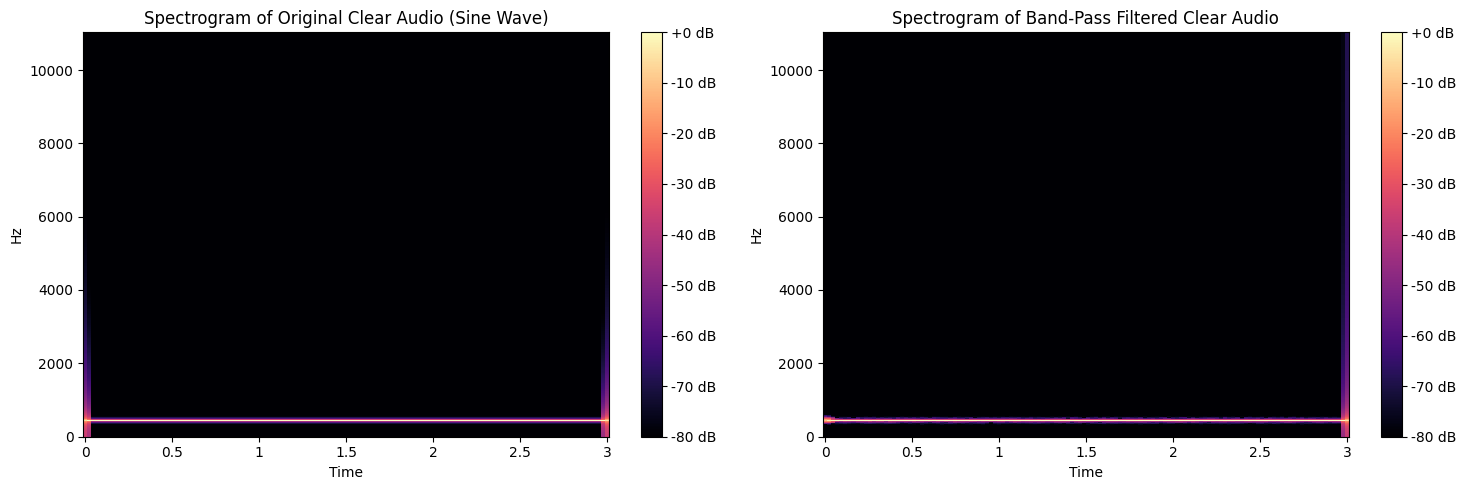

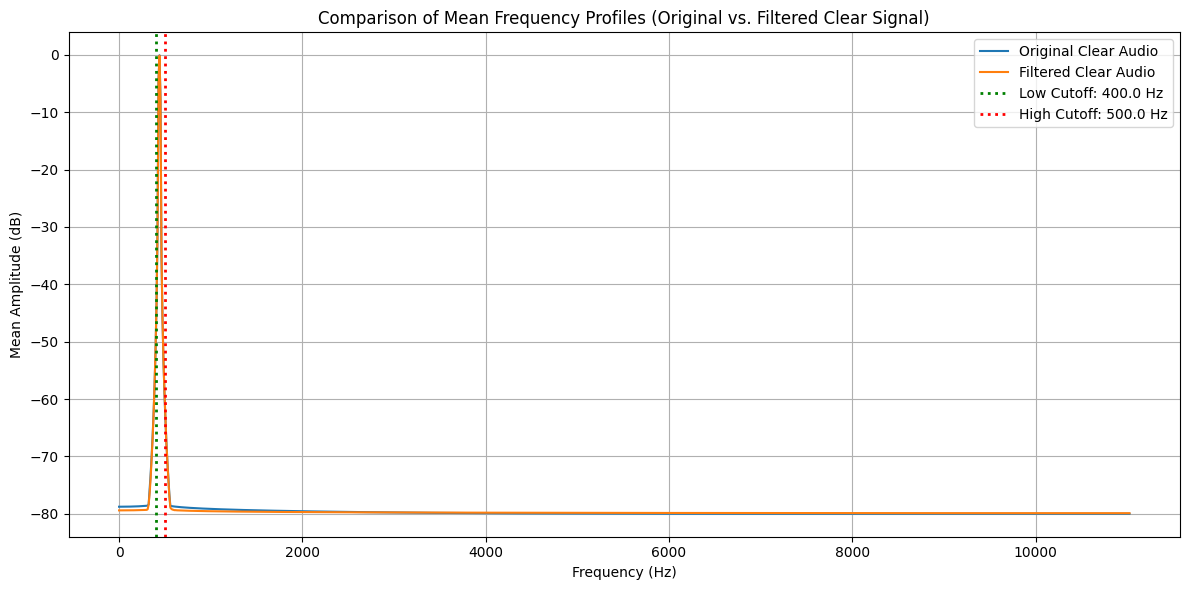

Spectrograms and mean frequency profiles for original and filtered clear signals visualized.


In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(S_db_clear, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Original Clear Audio (Sine Wave)')

plt.subplot(1, 2, 2)
librosa.display.specshow(S_db_clear_filtered, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Band-Pass Filtered Clear Audio')

plt.tight_layout()
plt.show()

# Compare mean frequency profiles
mean_amplitude_clear_filtered = np.mean(S_db_clear_filtered, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(freqs, mean_amplitude_clear, label='Original Clear Audio')
plt.plot(freqs, mean_amplitude_clear_filtered, label='Filtered Clear Audio')
plt.axvline(x=lowcut, color='g', linestyle=':', linewidth=2, label=f'Low Cutoff: {lowcut} Hz')
plt.axvline(x=highcut, color='r', linestyle=':', linewidth=2, label=f'High Cutoff: {highcut} Hz')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Amplitude (dB)')
plt.title('Comparison of Mean Frequency Profiles (Original vs. Filtered Clear Signal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Spectrograms and mean frequency profiles for original and filtered clear signals visualized.")

In [ ]:
from scipy.signal import butter, lfilter

# Define band-pass filter parameters
lowcut = 400.0  # Hz, lower cutoff frequency
highcut = 500.0 # Hz, upper cutoff frequency
order = 5       # Filter order

# Normalize cutoff frequencies to Nyquist frequency (sr/2)
nyquist = 0.5 * sr
low = lowcut / nyquist
high = highcut / nyquist

# Design the Butterworth band-pass filter
b, a = butter(order, [low, high], btype='band')

# Apply the filter to the noise signal
y_noise_filtered = lfilter(b, a, y_noise)

print(f"Applied a band-pass filter from {lowcut} Hz to {highcut} Hz to the noise signal.")

Applied a band-pass filter from 400.0 Hz to 500.0 Hz to the noise signal.


In [ ]:
# Compute the STFT for the filtered noise
D_noise_filtered = librosa.stft(y_noise_filtered)

# Convert to decibels for human perception
S_db_noise_filtered = librosa.amplitude_to_db(np.abs(D_noise_filtered), ref=np.max)

print("Spectrogram data computed for the filtered noise.")
print(f"Shape of filtered noise STFT magnitude: {np.abs(D_noise_filtered).shape}")
print(f"Shape of filtered noise decibel spectrogram: {S_db_noise_filtered.shape}")

Spectrogram data computed for the filtered noise.
Shape of filtered noise STFT magnitude: (1025, 130)
Shape of filtered noise decibel spectrogram: (1025, 130)


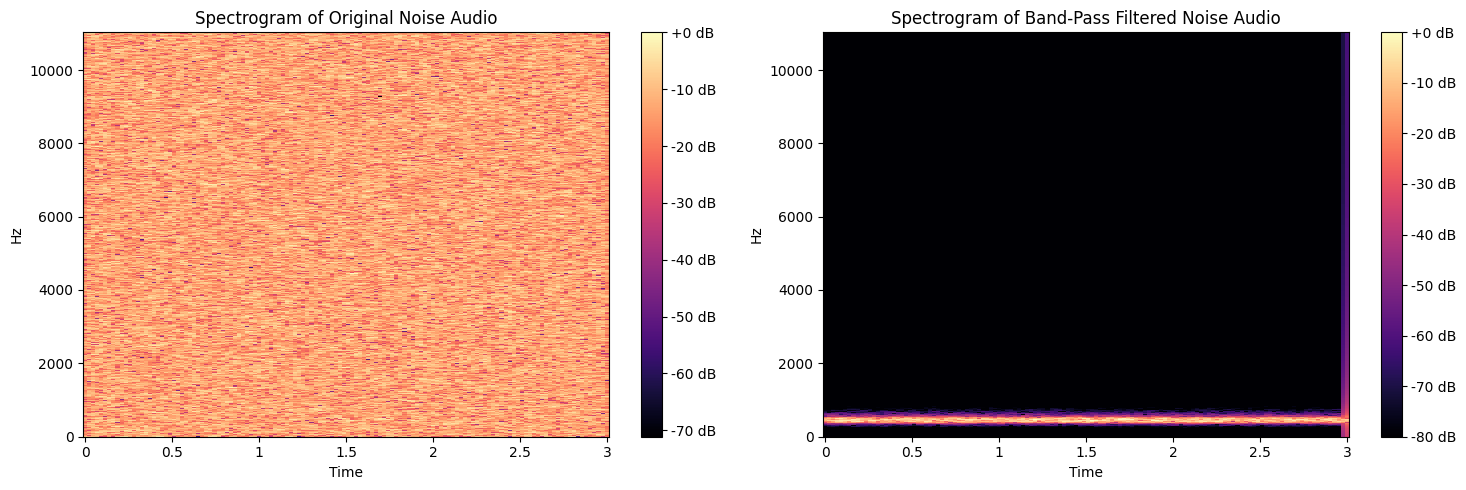

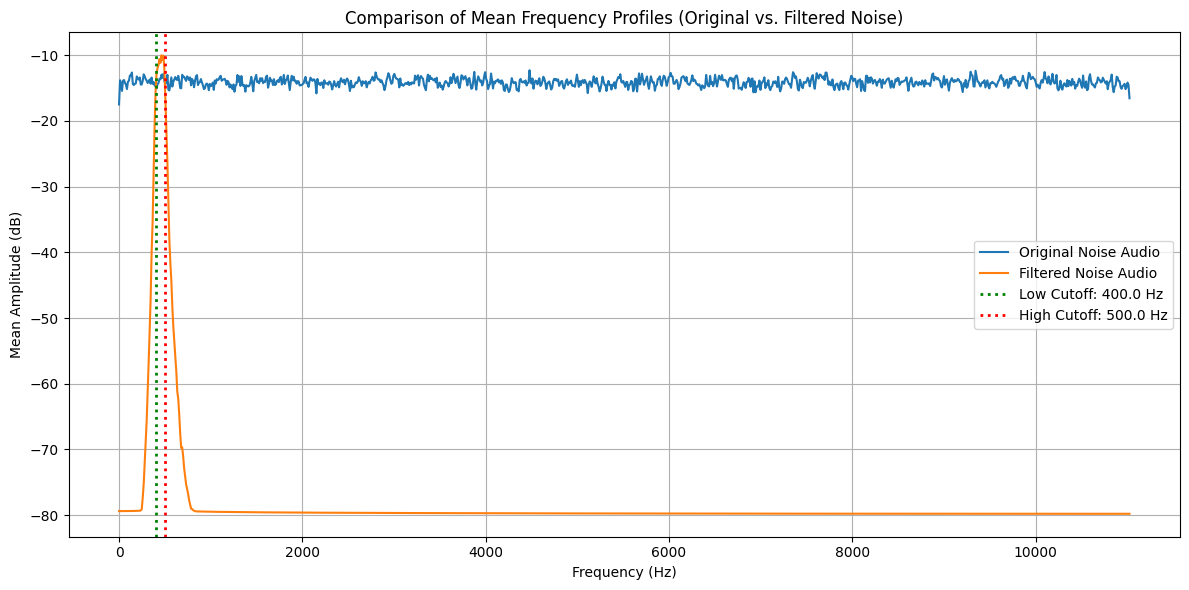

Spectrograms and mean frequency profiles for original and filtered noise visualized.


In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(S_db_noise, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Original Noise Audio')

plt.subplot(1, 2, 2)
librosa.display.specshow(S_db_noise_filtered, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Band-Pass Filtered Noise Audio')

plt.tight_layout()
plt.show()

# Compare mean frequency profiles
mean_amplitude_noise_filtered = np.mean(S_db_noise_filtered, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(freqs, mean_amplitude_noise, label='Original Noise Audio')
plt.plot(freqs, mean_amplitude_noise_filtered, label='Filtered Noise Audio')
plt.axvline(x=lowcut, color='g', linestyle=':', linewidth=2, label=f'Low Cutoff: {lowcut} Hz')
plt.axvline(x=highcut, color='r', linestyle=':', linewidth=2, label=f'High Cutoff: {highcut} Hz')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Amplitude (dB)')
plt.title('Comparison of Mean Frequency Profiles (Original vs. Filtered Noise)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Spectrograms and mean frequency profiles for original and filtered noise visualized.")

In [ ]:
# Get the frequency bins
freqs = librosa.fft_frequencies(sr=sr)

# Find the index of the maximum energy across all time frames
# We take the mean across time frames to get an average frequency profile
mean_amplitude = np.mean(S_db, axis=1)
peak_frequency_idx = np.argmax(mean_amplitude)
dominant_frequency = freqs[peak_frequency_idx]

print(f"Dominant frequency detected in the spectrogram: {dominant_frequency:.2f} Hz")

Dominant frequency detected in the spectrogram: 441.43 Hz


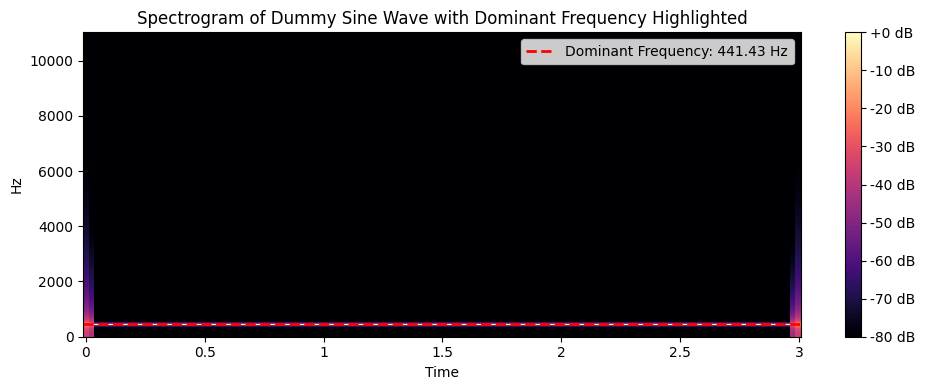

In [ ]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Dummy Sine Wave with Dominant Frequency Highlighted')

# Highlight the dominant frequency
plt.axhline(y=dominant_frequency, color='r', linestyle='--', linewidth=2, label=f'Dominant Frequency: {dominant_frequency:.2f} Hz')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

# Parameters for generating a dummy audio file
sr = 22050  # Sample rate
duration = 3 # seconds
f0 = 440    # Frequency of sine wave (Hz)

# Generate a dummy sine wave audio signal
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
y = 0.5 * np.sin(2 * np.pi * f0 * t) # Pure sine wave

# You can save this to a file if you want, but for demonstration, we'll keep it in memory
# sf.write('dummy_audio.wav', y, sr)
# print("Generated dummy_audio.wav")

print(f"Generated a dummy audio signal with sample rate {sr} Hz and duration {duration} seconds.")
print("Its shape is: ", y.shape)

Generated a dummy audio signal with sample rate 22050 Hz and duration 3 seconds.
Its shape is:  (66150,)


In [ ]:
# Compute the STFT
D = librosa.stft(y)

# Convert to decibels for human perception
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

print("Spectrogram data computed.")
print("Shape of the STFT magnitude (frequency bins x time frames): ", np.abs(D).shape)
print("Shape of the decibel spectrogram: ", S_db.shape)

Spectrogram data computed.
Shape of the STFT magnitude (frequency bins x time frames):  (1025, 130)
Shape of the decibel spectrogram:  (1025, 130)


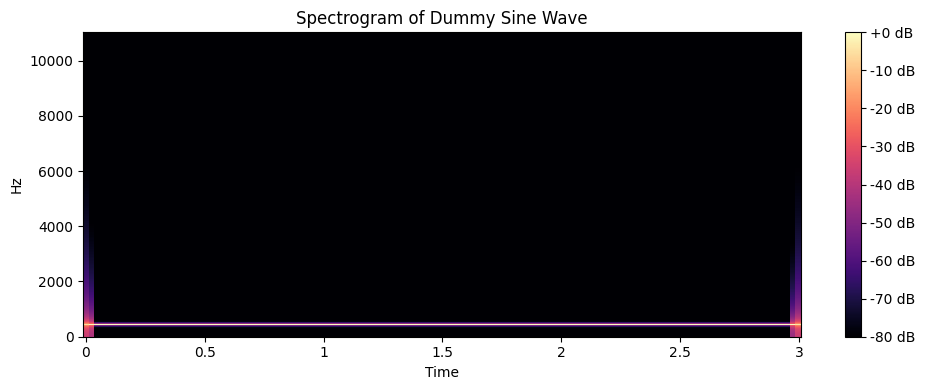

In [ ]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Dummy Sine Wave')
plt.tight_layout()
plt.show()

In [ ]:
y_noise = 0.1 * np.random.randn(len(y))

print(f"Generated a dummy noise audio signal. Its shape is: {y_noise.shape}")

Generated a dummy noise audio signal. Its shape is: (66150,)


In [ ]:
D_clear = librosa.stft(y)
S_db_clear = librosa.amplitude_to_db(np.abs(D_clear), ref=np.max)

D_noise = librosa.stft(y_noise)
S_db_noise = librosa.amplitude_to_db(np.abs(D_noise), ref=np.max)

print("STFT and decibel spectrograms computed for both clear and noise audio signals.")
print(f"Shape of clear audio STFT magnitude: {np.abs(D_clear).shape}")
print(f"Shape of clear audio decibel spectrogram: {S_db_clear.shape}")
print(f"Shape of noise audio STFT magnitude: {np.abs(D_noise).shape}")
print(f"Shape of noise audio decibel spectrogram: {S_db_noise.shape}")

STFT and decibel spectrograms computed for both clear and noise audio signals.
Shape of clear audio STFT magnitude: (1025, 130)
Shape of clear audio decibel spectrogram: (1025, 130)
Shape of noise audio STFT magnitude: (1025, 130)
Shape of noise audio decibel spectrogram: (1025, 130)


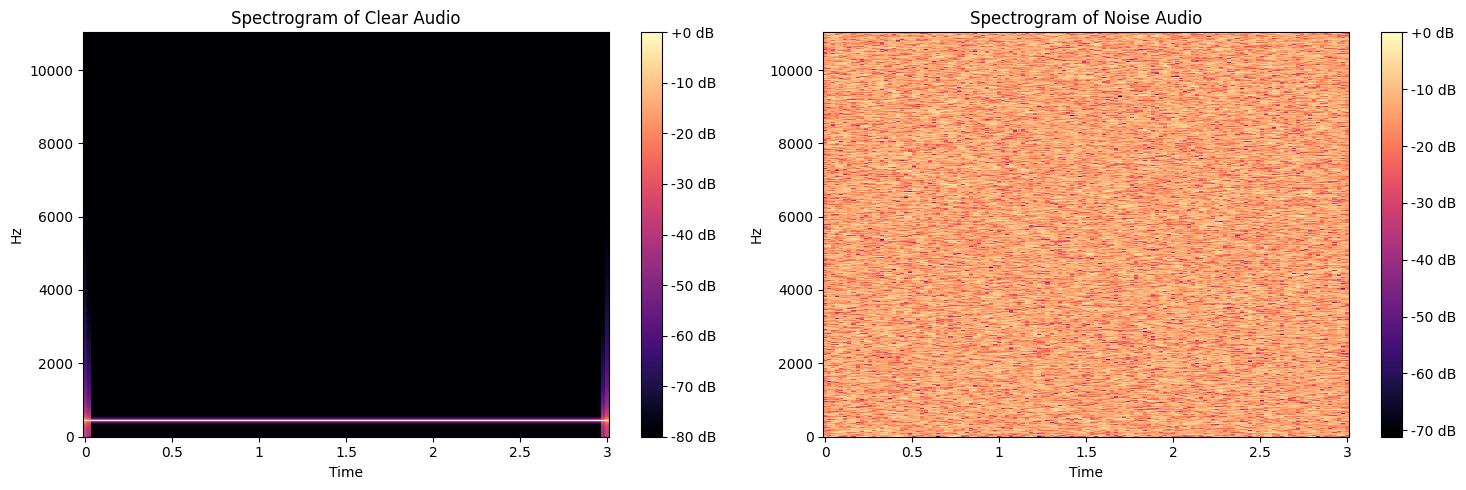

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(S_db_clear, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Clear Audio')

plt.subplot(1, 2, 2)
librosa.display.specshow(S_db_noise, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Noise Audio')

plt.tight_layout()
plt.show()


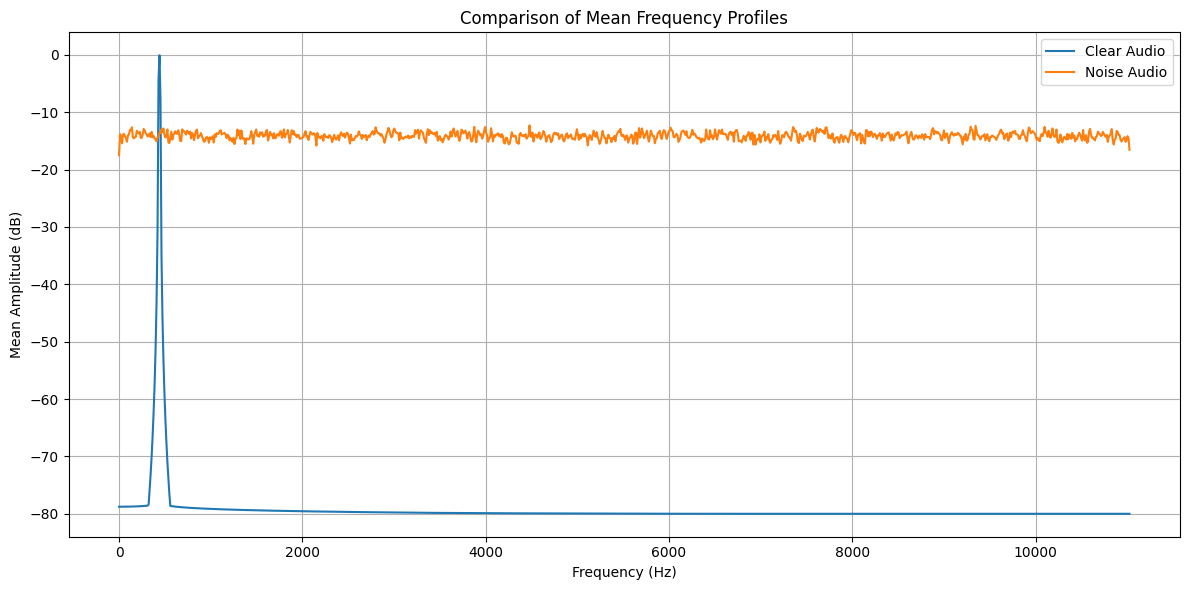

Mean frequency profiles calculated and plotted for clear and noise audio.


In [ ]:
mean_amplitude_clear = np.mean(S_db_clear, axis=1)
mean_amplitude_noise = np.mean(S_db_noise, axis=1)

freqs = librosa.fft_frequencies(sr=sr)

plt.figure(figsize=(12, 6))
plt.plot(freqs, mean_amplitude_clear, label='Clear Audio')
plt.plot(freqs, mean_amplitude_noise, label='Noise Audio')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Amplitude (dB)')
plt.title('Comparison of Mean Frequency Profiles')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Mean frequency profiles calculated and plotted for clear and noise audio.")

In [ ]:
from scipy.signal import butter

# Define low-pass filter parameters
cutoff_frequency = 1000.0  # Hz, cutoff frequency
order = 5              # Filter order

# Normalize cutoff frequency to Nyquist frequency (sr/2)
nyquist = 0.5 * sr
normalized_cutoff_frequency = cutoff_frequency / nyquist

# Design the Butterworth low-pass filter
b_lowpass, a_lowpass = butter(order, normalized_cutoff_frequency, btype='low')

print(f"Low-pass filter designed with cutoff frequency: {cutoff_frequency} Hz and order: {order}.")

Low-pass filter designed with cutoff frequency: 1000.0 Hz and order: 5.


In [ ]:
from scipy.signal import lfilter

# Apply the low-pass filter to the noise signal
y_noise_lowpass_filtered = lfilter(b_lowpass, a_lowpass, y_noise)

print(f"Low-pass filter applied to the noise signal with cutoff frequency: {cutoff_frequency} Hz.")

Low-pass filter applied to the noise signal with cutoff frequency: 1000.0 Hz.


In [ ]:
D_noise_lowpass_filtered = librosa.stft(y_noise_lowpass_filtered)
S_db_noise_lowpass_filtered = librosa.amplitude_to_db(np.abs(D_noise_lowpass_filtered), ref=np.max)

print("Spectrogram data computed for the low-pass filtered noise signal.")
print(f"Shape of low-pass filtered noise STFT magnitude: {np.abs(D_noise_lowpass_filtered).shape}")
print(f"Shape of low-pass filtered noise decibel spectrogram: {S_db_noise_lowpass_filtered.shape}")

Spectrogram data computed for the low-pass filtered noise signal.
Shape of low-pass filtered noise STFT magnitude: (1025, 130)
Shape of low-pass filtered noise decibel spectrogram: (1025, 130)


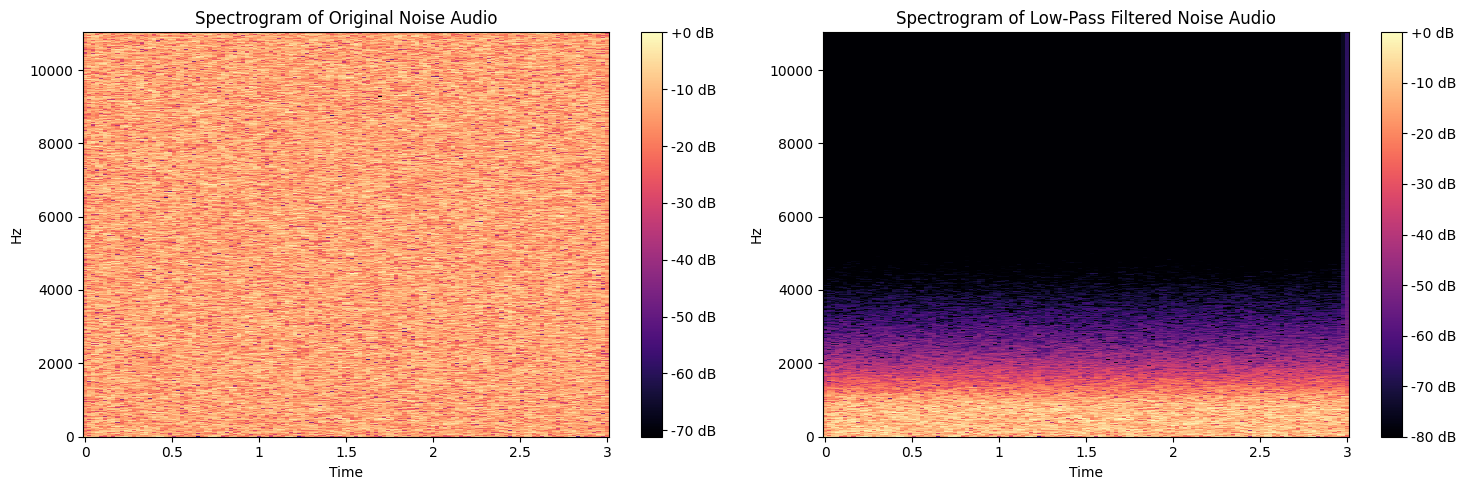

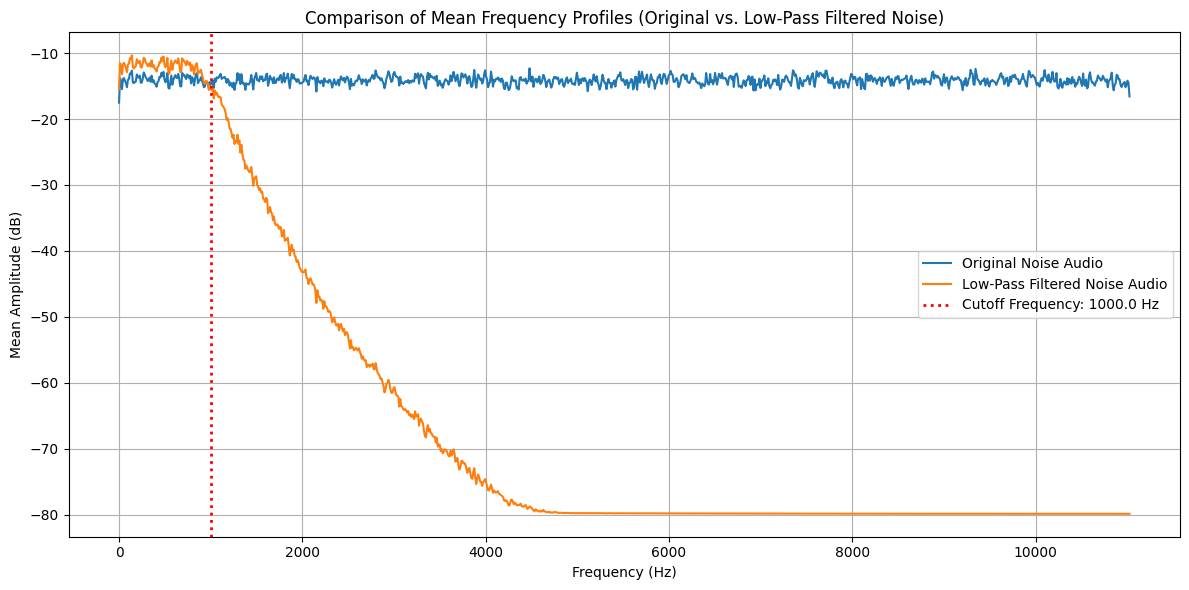

Spectrograms and mean frequency profiles for original and low-pass filtered noise visualized.


In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(S_db_noise, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Original Noise Audio')

plt.subplot(1, 2, 2)
librosa.display.specshow(S_db_noise_lowpass_filtered, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Low-Pass Filtered Noise Audio')

plt.tight_layout()
plt.show()

# Compare mean frequency profiles
mean_amplitude_noise_lowpass_filtered = np.mean(S_db_noise_lowpass_filtered, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(freqs, mean_amplitude_noise, label='Original Noise Audio')
plt.plot(freqs, mean_amplitude_noise_lowpass_filtered, label='Low-Pass Filtered Noise Audio')
plt.axvline(x=cutoff_frequency, color='r', linestyle=':', linewidth=2, label=f'Cutoff Frequency: {cutoff_frequency} Hz')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Amplitude (dB)')
plt.title('Comparison of Mean Frequency Profiles (Original vs. Low-Pass Filtered Noise)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Spectrograms and mean frequency profiles for original and low-pass filtered noise visualized.")